# Introduction

This notebook will show a demo of how to use the cebra_lens package on the Allen visual dataset. Some functions can handle both HPC and visual but the focus is on the visual dataset. As a prerequisite for the notebook you should have models already trained. If not, you can refer to the `ModelGeneratorVISUAL.ipnyb` notebook.

The folder structure should be as follows:


```
x/
├── data/
└── GithubFolder/
```

You should be in the `x/` directory, which is the parent directory of both `data/` and `GithubFolder/`.


In [2]:
cd ../../

d:\EPFL\MA2\project


c:\Users\Eloise\miniconda3\envs\cebra\Lib\site-packages\IPython\core\magics\osm.py:417: UserWarning: This is now an optional IPython functionality, setting dhist requires you to install the `pickleshare` library.
  self.shell.db['dhist'] = compress_dhist(dhist)[-100:]


In [3]:
import pickle
from tqdm import tqdm

from GithubFolder import cebra_lens as lens

In [4]:
models = lens.model_loader("D:\EPFL\MA2\project\FinalModels\VISION\offset10")

UnpicklingError: Weights only load failed. This file can still be loaded, to do so you have two options, [1mdo those steps only if you trust the source of the checkpoint[0m. 
	(1) In PyTorch 2.6, we changed the default value of the `weights_only` argument in `torch.load` from `False` to `True`. Re-running `torch.load` with `weights_only` set to `False` will likely succeed, but it can result in arbitrary code execution. Do it only if you got the file from a trusted source.
	(2) Alternatively, to load with `weights_only=True` please check the recommended steps in the following error message.
	WeightsUnpickler error: Unsupported global: GLOBAL cebra.data.datatypes.Offset was not an allowed global by default. Please use `torch.serialization.add_safe_globals([Offset])` or the `torch.serialization.safe_globals([Offset])` context manager to allowlist this global if you trust this class/function.

Check the documentation of torch.load to learn more about types accepted by default with weight

# Step 1: Parameter setup

In [4]:
session_id = 3
model_name = "offset10"
model_path = "FinalModels/VISION"
layer_type = "conv"  # where to attach the hooks (can be "all" or "conv")
activations_filepath = f"data/activations/{model_name}.pkl"
dataset_label = "visual"

# layer decoding
run_layer_decoding = False
decoding_filepath = f"data/decoding/{model_name}.pkl"
# tSNE
run_tsne = False  # to run the tSNE in section 5.
tSNE_filepath = f"data/tSNE/{model_name}.pkl"
num_samples_tSNE = 2000  # how many samples to run tSNE on

# CKA
run_CKA = False
cka_filepath = f"data/CKA/{model_name}.pkl"
comparisons = [
    ("single_UT", "single_TR"),
    ("multi_UT", "multi_TR"),
    ("single_TR", "multi_TR"),
    ("single_TR", "single_TR"),
    ("multi_TR", "multi_TR"),
]  # the comparison for the CKA

# RDM
run_rdm_example = True  # run the single example
run_RDM = False  # run the full analysis
rdm_filepath = f"data/RDM/{model_name}.pkl"

# Distances
run_distances = True
distance_filepath = f"data/distances/{model_name}.pkl"
metric = "cosine"

# Step 2: Load data and models

The second step is to load the data and the models. Data is loaded here with a utils function for the Allen dataset. Models are loaded by using the name of the folder where they are located as well as the folder path. It will load all the models ending with _torch.pt located in the path, thus these models should be saved as **torch** and not as sklearn. This was done due to easier loading on the CPU compared to the sklearn.

In [5]:
train_datas, valid_datas, discrete_labels_train, discrete_labels_val = (
    lens.utils_allen.get_single_session_datasets()
)

train_data = train_datas[session_id].neural
test_data = valid_datas[session_id].neural
train_label = discrete_labels_train[session_id]
test_label = discrete_labels_val[session_id]

In [8]:
models = lens.model.model_loader(model_path=model_path, model_name=model_name)

Number of models:  12
['allen_multi_session_0k_UT_torch.pt', 'allen_multi_session_10k_0_torch.pt', 'allen_multi_session_10k_1_torch.pt', 'allen_multi_session_10k_2_torch.pt', 'allen_multi_session_10k_3_torch.pt', 'allen_multi_session_10k_4_torch.pt', 'allen_single_session_mouse4_0k_UT_torch.pt', 'allen_single_session_mouse4_10k_0_torch.pt', 'allen_single_session_mouse4_10k_1_torch.pt', 'allen_single_session_mouse4_10k_2_torch.pt', 'allen_single_session_mouse4_10k_3_torch.pt', 'allen_single_session_mouse4_10k_4_torch.pt']


UnpicklingError: Weights only load failed. This file can still be loaded, to do so you have two options, [1mdo those steps only if you trust the source of the checkpoint[0m. 
	(1) In PyTorch 2.6, we changed the default value of the `weights_only` argument in `torch.load` from `False` to `True`. Re-running `torch.load` with `weights_only` set to `False` will likely succeed, but it can result in arbitrary code execution. Do it only if you got the file from a trusted source.
	(2) Alternatively, to load with `weights_only=True` please check the recommended steps in the following error message.
	WeightsUnpickler error: Unsupported global: GLOBAL cebra.integrations.sklearn.cebra.CEBRA was not an allowed global by default. Please use `torch.serialization.add_safe_globals([CEBRA])` or the `torch.serialization.safe_globals([CEBRA])` context manager to allowlist this global if you trust this class/function.

Check the documentation of torch.load to learn more about types accepted by default wi

# Step 3
## A: Model decoding

To verify the model performance the decode_models function can be called. This will give a dictionnary with each key being the name of the model "single_UT" "multi_TR" ... and plot the performance accordingly. This is flexible and can thus take many different models.

In [ ]:
results_dict = lens.quantification.decoding.decode_models(
    models=models,
    train_data=train_data,
    train_label=train_label,
    test_data=test_data,
    test_label=test_label,
    session_id=session_id,
)
print(results_dict.keys())

dict_keys(['single_UT', 'multi_UT', 'single_TR', 'multi_TR'])


In [ ]:
results_dict

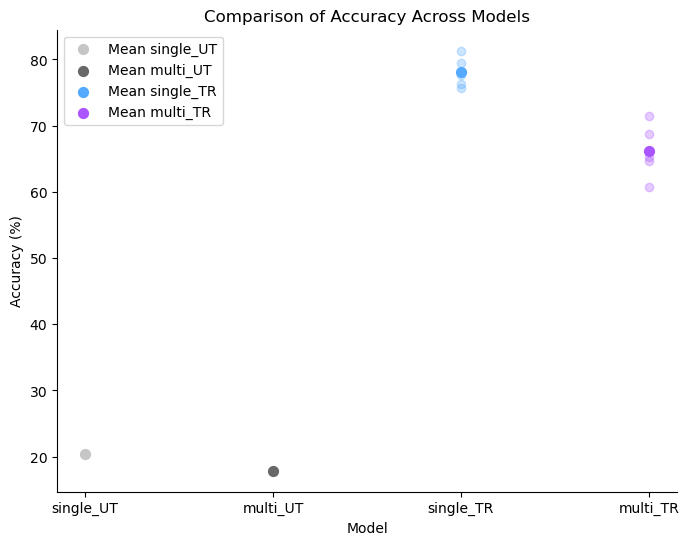

In [ ]:
fig = lens.plotting.plot_decoding(results_dict=results_dict, palette_tr="cool")

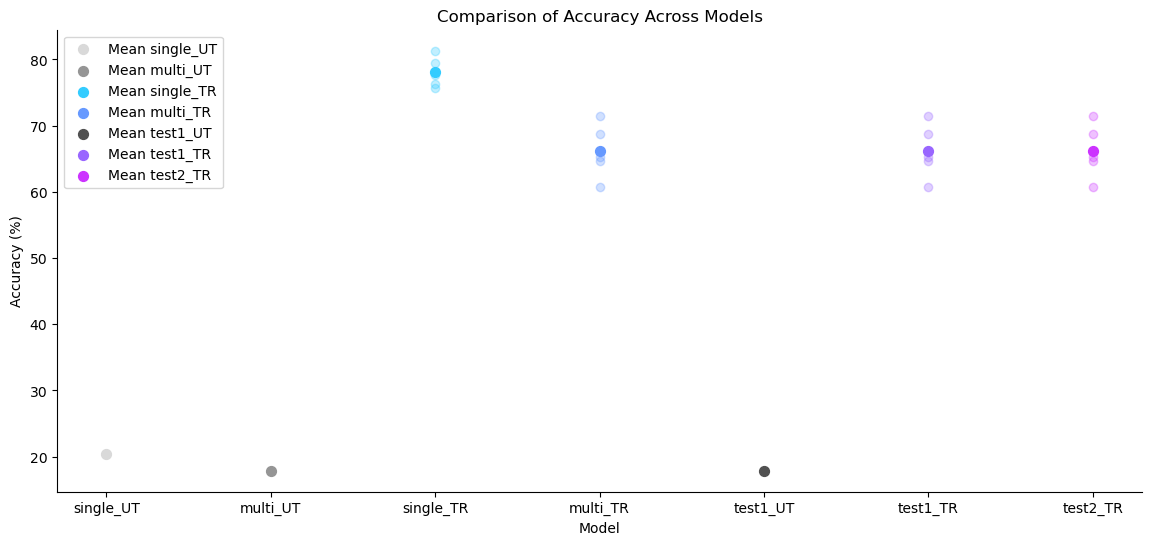

In [ ]:
# ex adding more models
results_dict_test = results_dict.copy()
results_dict_test["test1_UT"] = results_dict["multi_UT"]
results_dict_test["test1_TR"] = results_dict["multi_TR"]
results_dict_test["test2_TR"] = results_dict["multi_TR"]

fig = lens.plotting.plot_decoding(results_dict=results_dict_test, palette_tr="cool")

## B: Model decoding by layer

Decoding can also be done by layer. Here the layer activations are already taken from the model inside of the function for simplicity. In the following sections it will be separated for clarity of use.

In [ ]:
if run_layer_decoding:
    results_dict = lens.quantification.decoding.decode_by_layer_all(
        models_dict=models,
        train_data=train_data,
        train_label=train_label,
        test_data=test_data,
        test_label=test_label,
        session_id=session_id,
        dataset_label=dataset_label,
        layer_type=layer_type,
    )

    with open(decoding_filepath, "wb") as f:
        pickle.dump(results_dict, f)
else:
    with open(decoding_filepath, "rb") as f:
        results_dict = pickle.load(f)

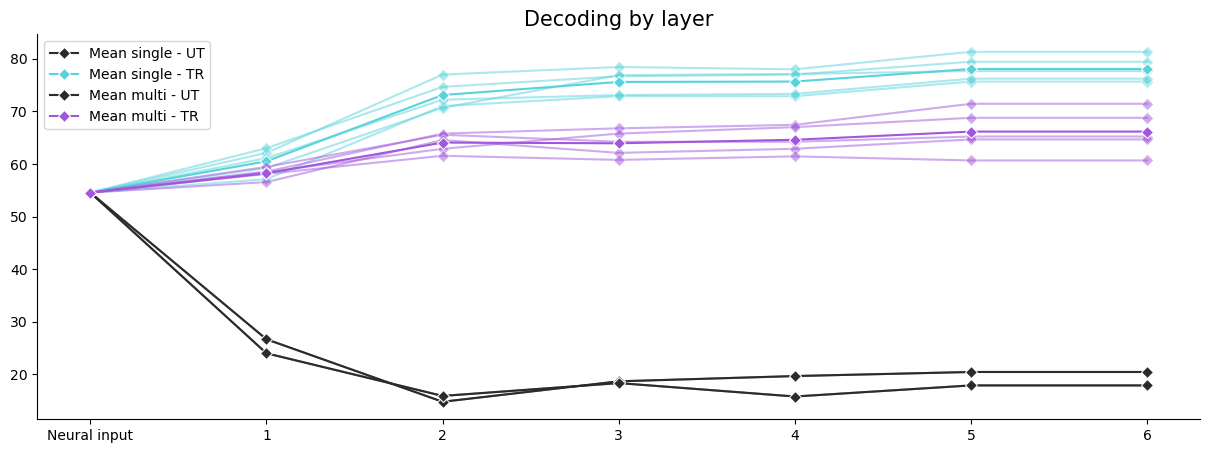

In [ ]:
fig = lens.plotting.plot_layer_decoding(results_dict=results_dict)

# Step 4: Retrieve activations

Now, the activations can be retrieved simply by calling the function get_activations_multi_model. This will gather them in a dictionnary that for now has the outer keys as the solver type ("single", "multi") and the inner key is "TR" or "UT". This structure is replicated for everything that follows such as RDM, CKA, tSNE...

In [ ]:
activations = {}
activations = lens.activations.get_activations_multi_model(
    models=models,
    data=train_data,
    session_id=session_id,
    activations=activations,
    layer_type=layer_type,
)

activations_dict = lens.activations.process_activations(activations)

with open(activations_filepath, "wb") as f:
    pickle.dump(activations_dict, f)

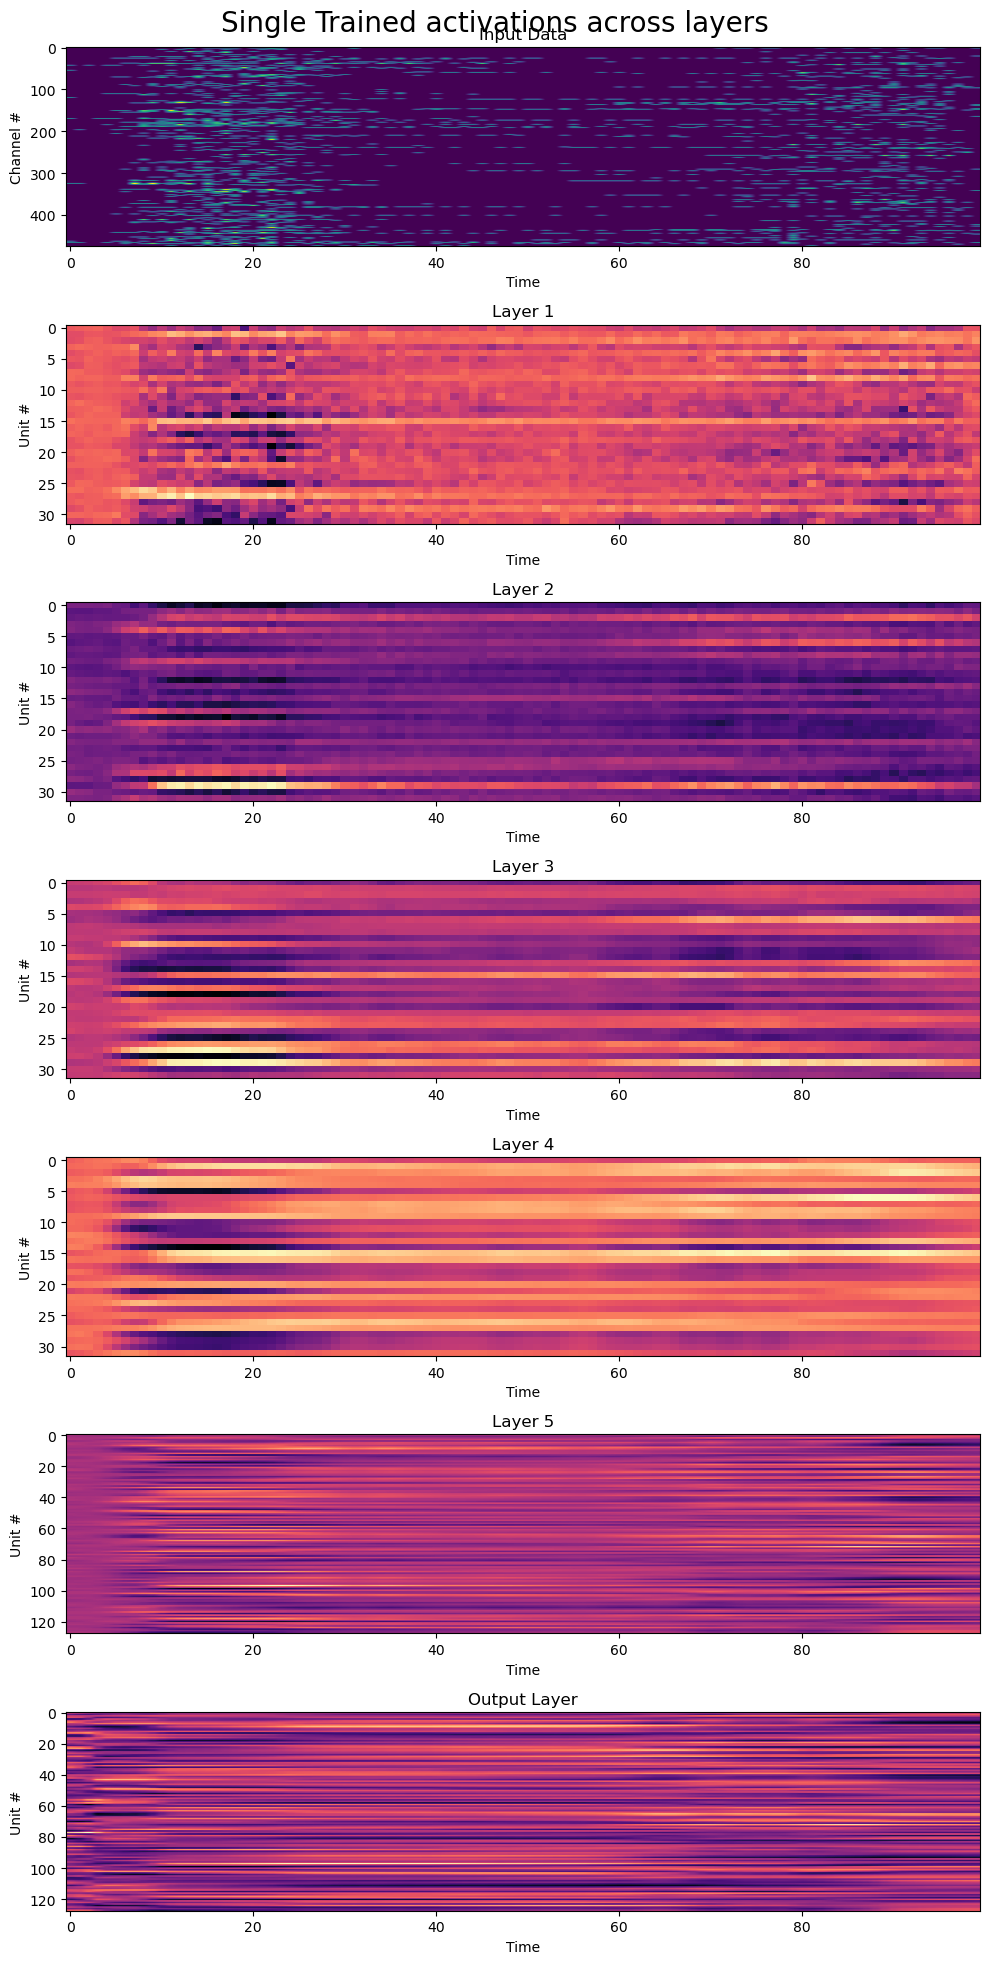

In [ ]:
# The activations per layer can be plotted to see that everything is as expected
fig = lens.plotting.plot_simple_activations(
    train_data,
    activations_dict["single"]["TR"][0],
    title="Single Trained activations across layers",
    figsize=(7, 14),
)

# Step 5: visualization

Embeddings can be visualized, either in tsne or in high dimensionality.

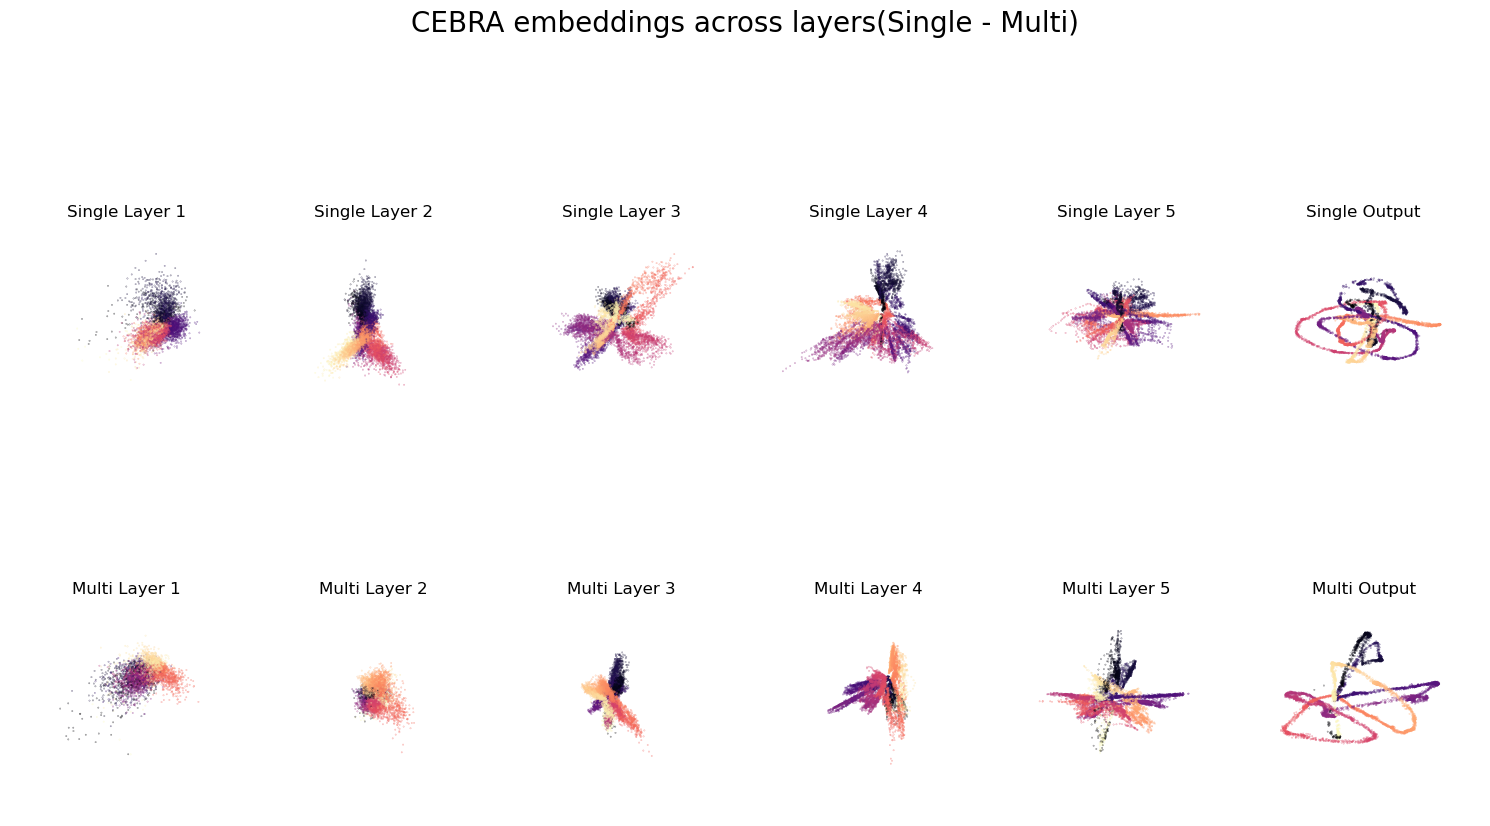

In [ ]:
# High dimensionality can be plotted together or alone (see lens.plotting.plot_embedding_layers)

fig = lens.plotting.compare_embeddings_layers(
    activations_dict["single"]["TR"][0],
    activations_dict["multi"]["TR"][0],
    labels=train_label,
    dataset_label=dataset_label,
    sample_plot=activations_dict["multi"]["TR"][0][0].shape[1],
    comparison_labels=("CEBRA embeddings", ["Single", "Multi"]),
)

For the tSNE it can be either ran and saved or loaded directly. As it takes time to run, it is better to load it if saved already.

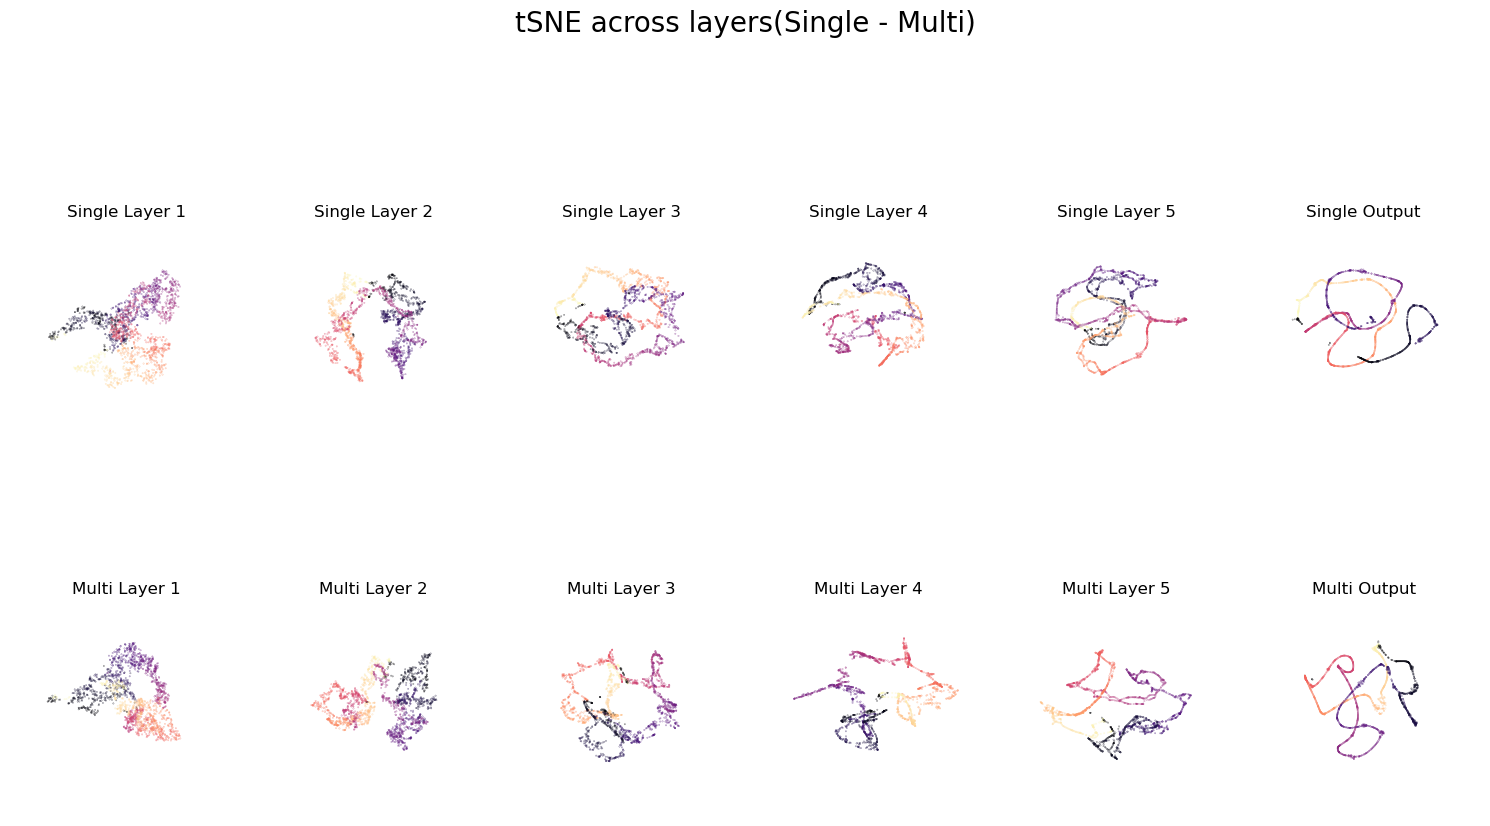

In [ ]:
if run_tsne:

    tSNE_dict = lens.transform.run_tsne_and_save(
        activations_dict, tSNE_filepath, num_samples_tSNE
    )

else:
    with open(tSNE_filepath, "rb") as f:
        tSNE_dict = pickle.load(f)


fig = lens.plotting.compare_embeddings_layers(
    tSNE_dict["single"]["TR"][0],
    tSNE_dict["multi"]["TR"][0],
    labels=train_label,
    dataset_label=dataset_label,
    sample_plot=num_samples_tSNE,
    comparison_labels=("tSNE", ["Single", "Multi"]),
)

# Step 6: CKA Analysis

Here again, it takes quite some time to run the CKA. Load if already computed. To compute the CKA you can chose the desired comparisons and it will create the CKA matrix accordingly. See the parameters in the first section, these comparisons are a list of tuples.

For the plotting here again the desired comparisons can be chosen and the plot will adapt accordinly.

In [ ]:
if run_CKA:
    comparisons = [
        ("single_UT", "single_TR"),
        ("multi_UT", "multi_TR"),
        ("single_TR", "multi_TR"),
        ("single_TR", "single_TR"),
        ("multi_TR", "multi_TR"),
    ]

    cka_matrices = {}
    for comparison in tqdm(comparisons):
        cka_matrix = lens.quantification.compute_multi_CKA_layers(
            activations_dict=activations_dict, comparison=comparison
        )
        cka_matrices[f"{comparison[0]}_v_{comparison[1]}"] = cka_matrix

    with open(cka_filepath, "wb") as f:
        pickle.dump(cka_matrices, f)
        print(f"Succesfully saved the matrices here: {cka_filepath} ")

else:
    with open(cka_filepath, "rb") as f:
        cka_matrices = pickle.load(f)

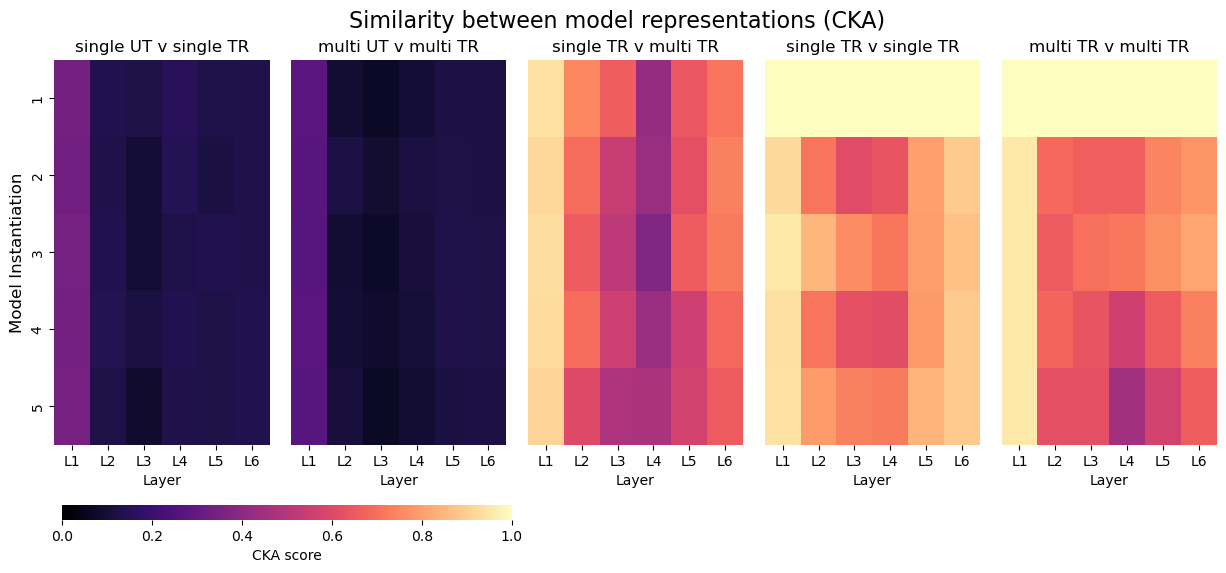

In [ ]:
fig = lens.plotting.plot_cka_heatmaps(
    cka_matrices=cka_matrices,
    annot=False,
)

In [ ]:
keys = list(cka_matrices.keys())
cka_matrices_small = {key: cka_matrices[key] for key in keys[0:3]}

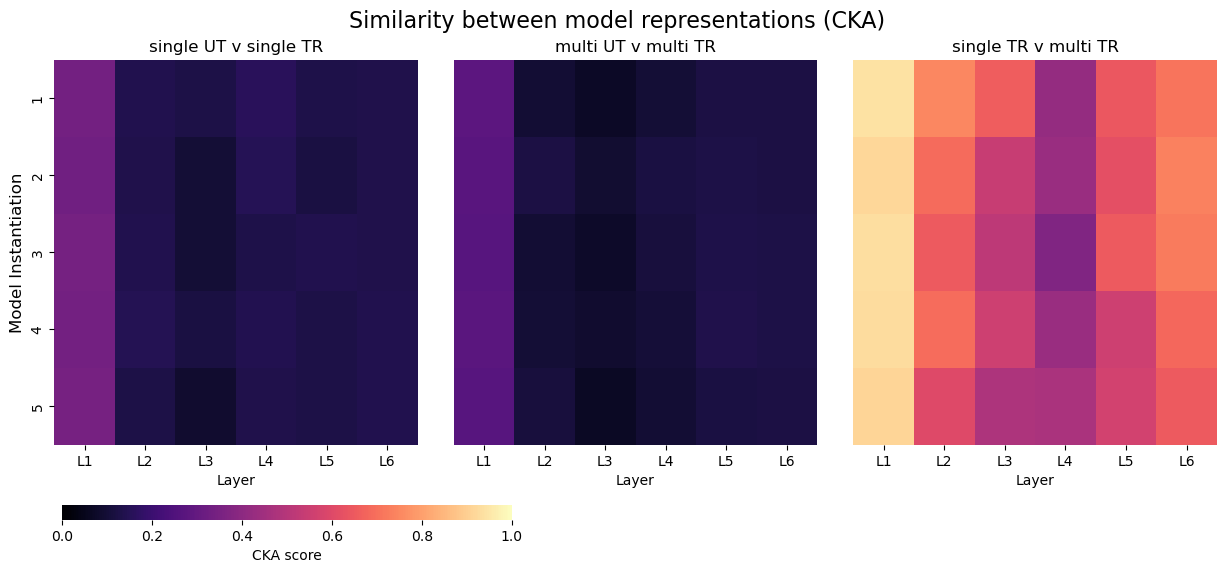

In [ ]:
fig = lens.plotting.plot_cka_heatmaps(
    cka_matrices=cka_matrices_small,
    annot=False,
)

# Step 7: RDM Analysis

RDM Matrices are huge to save (20Go) but not so long to compute. Be careful when saving it, comment if needed or at least delete it when no longer needed it. rdm_dict will have the same format as activation_dict. It computes the RDM for the whole activation dataset, but smaller datasets can be inputted. It also has the possibility to correlate it to Oracle RDM.

First, we can show an example of an RDM computed on all layers of a model instance. We can plot the desired layers.

In [ ]:
if run_rdm_example:
    multi_rdm_corr = lens.quantification.RDM.compute_single_RDM_layers(
        data=train_data,
        label=train_label,
        activations=activations_dict["multi"]["TR"][0],
        metric="correlation",
        bool_oracle=False,
    )

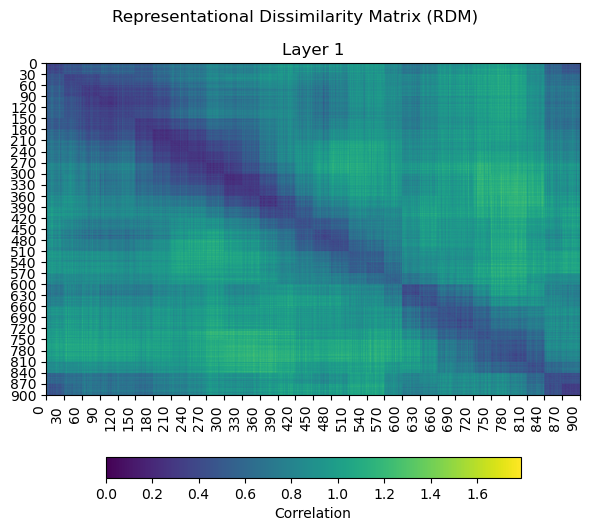

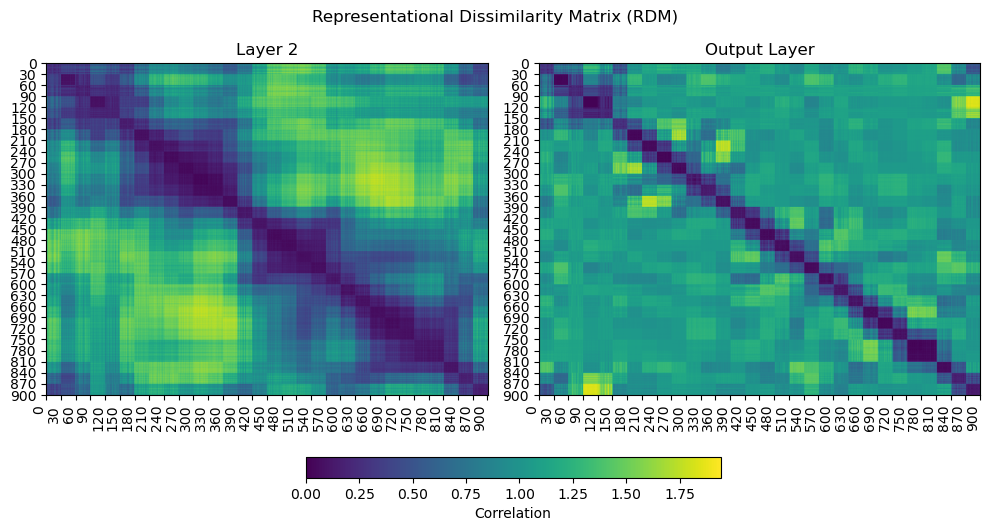

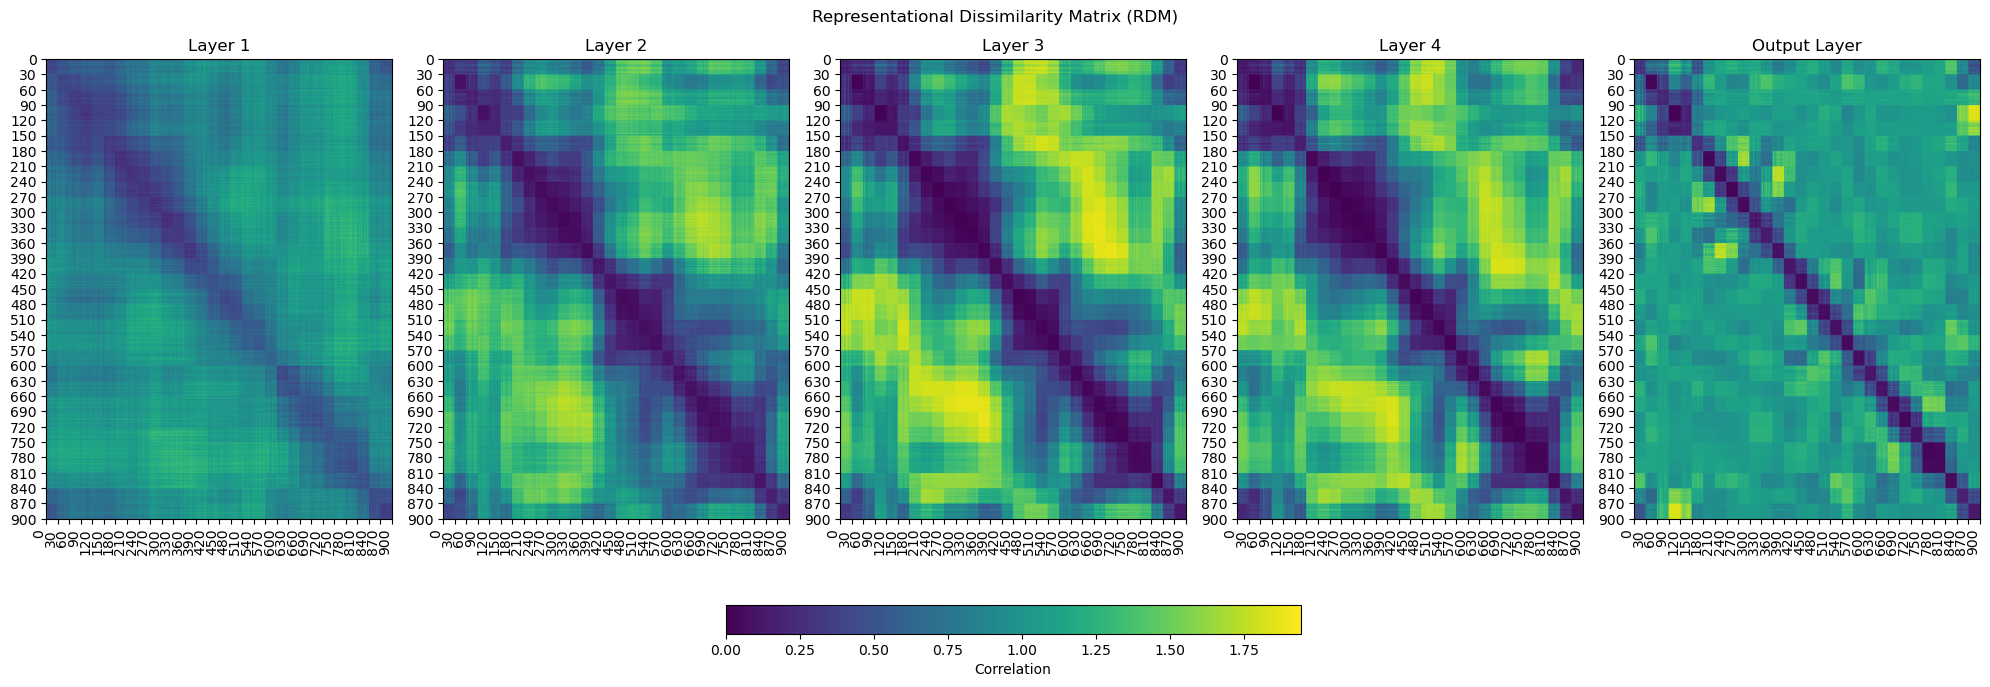

In [ ]:
if run_rdm_example:
    fig = lens.plotting.plot_rdm(
        [multi_rdm_corr[0][0]],
        ["Layer 1"],
        metric="Correlation",
    )
    fig2 = lens.plotting.plot_rdm(
        [multi_rdm_corr[1][0], multi_rdm_corr[-1][0]],
        ["Layer 2", "Output Layer"],
        metric="Correlation",
    )
    fig3 = lens.plotting.plot_rdm(
        [
            multi_rdm_corr[0][0],
            multi_rdm_corr[1][0],
            multi_rdm_corr[2][0],
            multi_rdm_corr[3][0],
            multi_rdm_corr[-1][0],
        ],
        ["Layer 1", "Layer 2", "Layer 3", "Layer 4", "Output Layer"],
        metric="Correlation",
        figsize=(20, 8),
    )

Secondly, we can compute the analysis on all instances and all models by passing the dictionnary activations.

In [ ]:
if run_RDM:

    rdm_dict = lens.quantification.RDM.compute_multi_RDM_layers(
        data=train_data,
        label=train_label,
        activations_dict=activations_dict,
        dataset_label=dataset_label,
        metric="correlation",
        bool_oracle=True,
    )
    with open(rdm_filepath, "wb") as f:
        pickle.dump(rdm_dict, f)

else:
    with open(rdm_filepath, "rb") as f:
        rdm_dict = pickle.load(f)

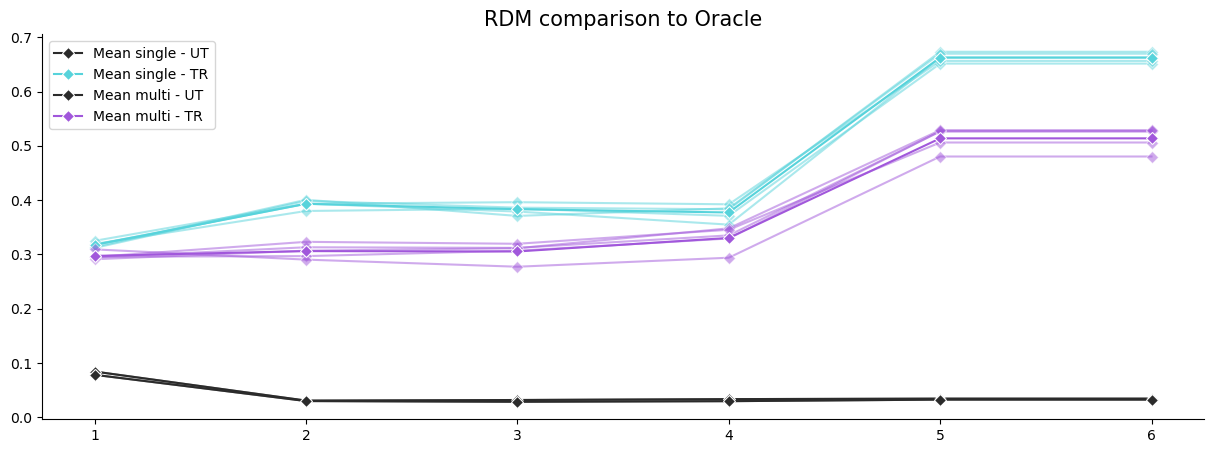

In [ ]:
fig = lens.plotting.plot_rdm_correlation(rdm_dict=rdm_dict)

# Step 8: Distance analysis

A final embedding analysis can be done using cebra_lens: a distance analysis. They all utilise the binning as described in RDM (c.f. `cebra_lens.quantification.misc.discrete_binning()`).
Three distances can be computed:
- inter-bin -> between the bins (irrespective of repetitions)
- intra-bin -> inside of each bin
- inter-repetition -> distance between each repetition by computing centroid of each bin at each repetition


In [ ]:
if run_distances:

    interbin_distances_dict = (
        lens.quantification.distance.compute_multi_distance_layers(
            data=train_data,
            label=train_label,
            activations_dict=activations_dict,
            dataset_label=dataset_label,
            metric=metric,
            distance_label="interbin",
        )
    )
    intrabin_distances_dict = (
        lens.quantification.distance.compute_multi_distance_layers(
            data=train_data,
            label=train_label,
            activations_dict=activations_dict,
            dataset_label=dataset_label,
            metric=metric,
            distance_label="intrabin",
        )
    )
    interrep_distances_dict = (
        lens.quantification.distance.compute_multi_distance_layers(
            data=train_data,
            label=train_label,
            activations_dict=activations_dict,
            dataset_label=dataset_label,
            metric=metric,
            distance_label="interrep",
        )
    )

    distances = {
        "inter-bin": interbin_distances_dict,
        "intra-bin": intrabin_distances_dict,
        "inter-rep": interrep_distances_dict,
    }
    with open(distance_filepath, "wb") as f:
        pickle.dump(distances, f)
else:
    with open(distance_filepath, "rb") as f:
        distances = pickle.load(f)

Processing multi: 100%|██████████| 2/2 [00:00<00:00,  4.37it/s]


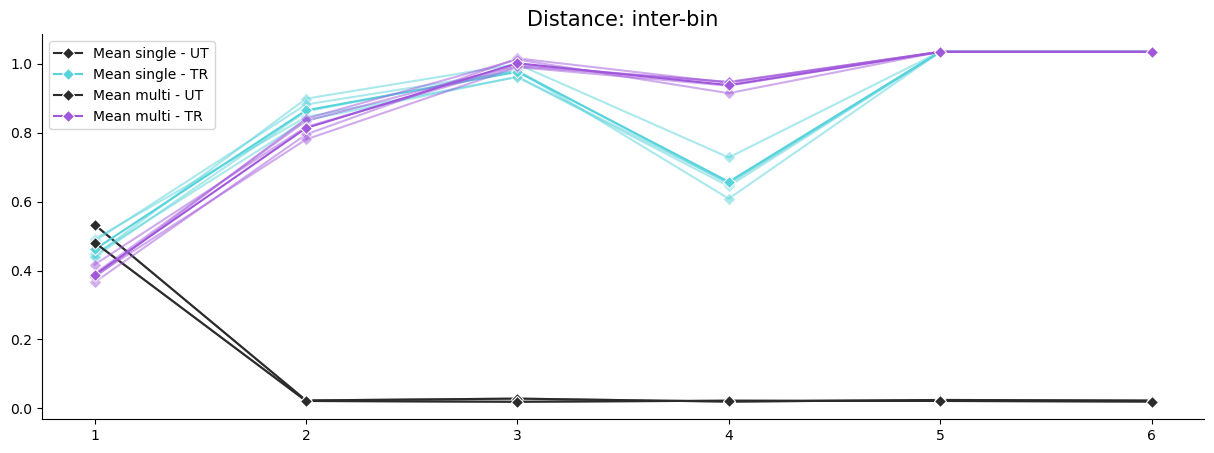

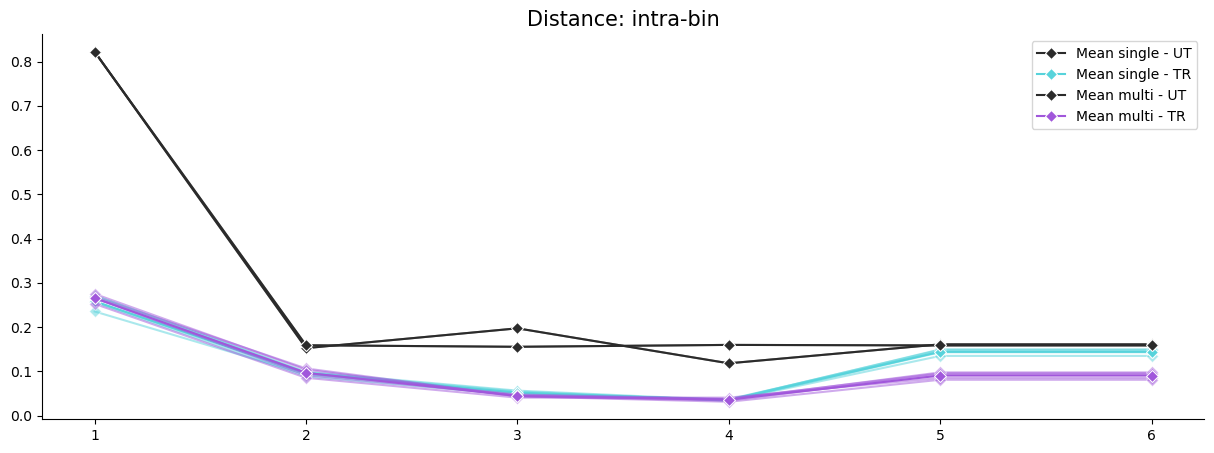

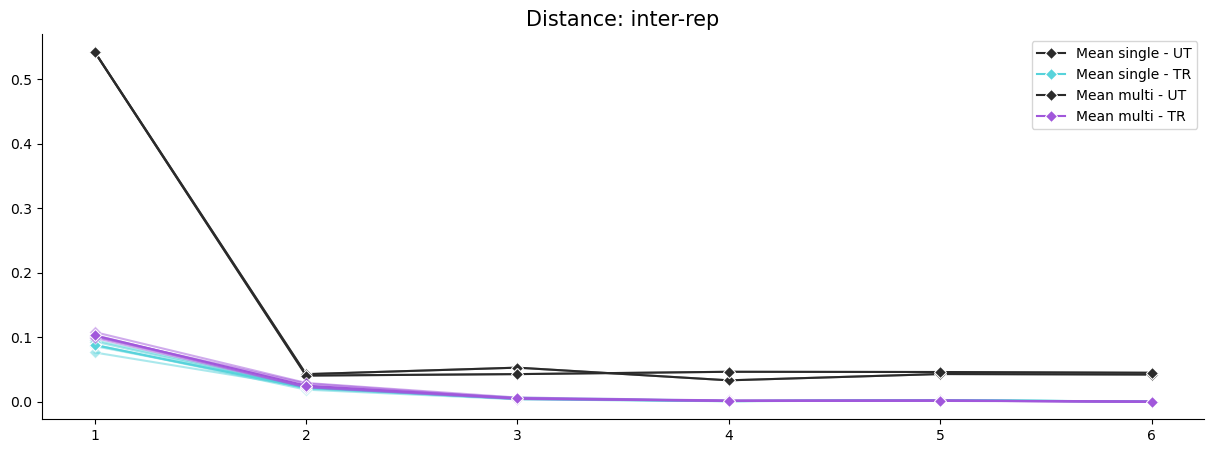

In [ ]:
figs = []
for key, value in distances.items():
    title = f"Distance: {key}"

    figs.append(lens.plotting.plot_distance(distance_dict=value, title=title))